In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive, Naive, HistoricAverage
import pandas as pd
import matplotlib.pyplot as plt
import random
from itertools import product
import matplotlib.dates as mdates

In [ ]:
from utilsforecast.data import generate_series

Y_df = generate_series(n_series=128, freq='ME', min_length=60, max_length=60, with_trend=True)
Y_df

,unique_id,ds,y
0,0,2000-01-31,0.274407
1,0,2000-02-29,2.227602
2,0,2000-03-31,4.041396
3,0,2000-04-30,5.882464
4,0,2000-05-31,7.691857
...,...,...,...
7675,127,2004-08-31,44.923498
7676,127,2004-09-30,46.361813
7677,127,2004-10-31,48.138033
7678,127,2004-11-30,49.535287


In [ ]:
sf = StatsForecast(
    models=[SeasonalNaive(season_length=12), Naive(), HistoricAverage()],
    freq='ME',
    n_jobs=-1
)

cv_df = sf.cross_validation(df=Y_df, h=12)
cv_df

,unique_id,ds,cutoff,y,SeasonalNaive,Naive,HistoricAverage
0,0,2004-01-31,2003-12-31,41.918068,31.626313,51.954809,26.218289
1,0,2004-02-29,2003-12-31,43.812216,33.498739,51.954809,26.218289
2,0,2004-03-31,2003-12-31,45.785467,35.532154,51.954809,26.218289
3,0,2004-04-30,2003-12-31,47.589676,37.271197,51.954809,26.218289
4,0,2004-05-31,2003-12-31,49.734570,38.980048,51.954809,26.218289
...,...,...,...,...,...,...,...
1531,127,2004-08-31,2003-12-31,44.923498,36.354514,43.117257,21.773173
1532,127,2004-09-30,2003-12-31,46.361813,38.185409,43.117257,21.773173
1533,127,2004-10-31,2003-12-31,48.138033,40.096793,43.117257,21.773173
1534,127,2004-11-30,2003-12-31,49.535287,41.398671,43.117257,21.773173


In [ ]:
cutoff = pd.Timestamp('2003-12-31')

In [ ]:
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse

df_eval = evaluate(cv_df, metrics=[mae, rmse], models=['SeasonalNaive', 'Naive', 'HistoricAverage'])
df_eval

,unique_id,cutoff,metric,SeasonalNaive,Naive,HistoricAverage
0,0,2003-12-31,mae,10.385087,5.577062,26.025675
1,1,2003-12-31,mae,7.175618,4.931577,17.871735
2,2,2003-12-31,mae,4.414868,4.718237,11.174016
3,3,2003-12-31,mae,0.999545,5.029895,3.747323
4,4,2003-12-31,mae,5.954271,4.808348,14.950838
...,...,...,...,...,...,...
251,123,2003-12-31,rmse,8.823970,5.917266,22.595332
252,124,2003-12-31,rmse,3.841348,5.698673,10.594876
253,125,2003-12-31,rmse,4.699834,5.533386,12.615176
254,126,2003-12-31,rmse,10.197017,6.425962,26.298619


In [ ]:
def plot_grid(df_train, df_test=None, df_eval=None, plot_random=True, model=None, level=None, ids=None, descs=None, date_fmt=None):
    if model is None and df_test is not None:
        models = [c for c in df_test.columns if c not in ('unique_id', 'ds', 'y', 'y_test', 'cutoff')]
        assert len(models) == 1, f"Multiple models found: {models}. Please specify `model`."
        model = models[0]
    fig, axes = plt.subplots(4, 2, figsize = (24, 16))

    unique_ids = df_train['unique_id'].unique()

    assert len(unique_ids) >= 8, "Must provide at least 8 ts"

    if plot_random:
        unique_ids = random.sample(list(unique_ids), k=8)
    else:
        unique_ids = ids

    for uid, (idx, idy) in zip(unique_ids, product(range(4), range(2))):
        train_uid = df_train.query('unique_id == @uid')
        line, = axes[idx, idy].plot(train_uid['ds'], train_uid['y'], label='y', )
        train_color = line.get_color()
        if df_test is not None:
            test_uid = df_test.query('unique_id == @uid')
            axes[idx, idy].axvline(x=test_uid['cutoff'].iloc[0], color='grey', linestyle='--', label='cutoff')
            for col in ['y', f'{model}', 'y_test']:
                if col in test_uid:
                    if col == 'y': axes[idx, idy].plot(test_uid['ds'], test_uid[col], color=train_color, label='_nolegend_')
                    else: axes[idx, idy].plot(test_uid['ds'], test_uid[col], label=col)
            if level is not None:
                for l, alpha in zip(sorted(level), [0.5, .4, .35, .2]):
                    axes[idx, idy].fill_between(
                        test_uid['ds'],
                        test_uid[f'{model}-lo-{l}'],
                        test_uid[f'{model}-hi-{l}'],
                        alpha=alpha,
                        color='orange',
                        label=f'{model}_level_{l}',
                    )

        # Build title — include MAE if eval data is available
        title = f'UID: {uid}'
        if descs is not None and uid in descs['unique_id'].values:
            title = f"{descs.query('unique_id == @uid')['desc'].values[0]} | {title}"
        if df_eval is not None and model is not None:
            eval_uid = df_eval.query('unique_id == @uid')
            if not eval_uid.empty and model in eval_uid.columns:
                metrics = ' | '.join(f'{r.metric}: {r[model]:.2f}' for _, r in eval_uid.iterrows())
                title += f' | {metrics}'
        axes[idx, idy].set_title(title, fontweight='bold')

        axes[idx, idy].set_xlabel('Date [m]')
        axes[idx, idy].set_ylabel('Target')
        axes[idx, idy].set_ylim(bottom=0)
        axes[idx, idy].legend(loc='upper left')
        if date_fmt in ('month', 'monthly'):
            axes[idx, idy].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
            axes[idx, idy].xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
        elif date_fmt == 'quarter':
            axes[idx, idy].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
            axes[idx, idy].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{mdates.num2date(x):%Y} Q{(mdates.num2date(x).month-1)//3+1}"))
        if date_fmt: plt.setp(axes[idx, idy].xaxis.get_majorticklabels(), rotation=45, ha='right')
        axes[idx, idy].grid()
    fig.subplots_adjust(hspace=0.5)
    plt.show()
    return None

In [ ]:
descs = pd.DataFrame(dict(unique_id=[0, 3, 7], desc=['Widget Sales', 'Gizmo Revenue', 'Sprocket Orders']))

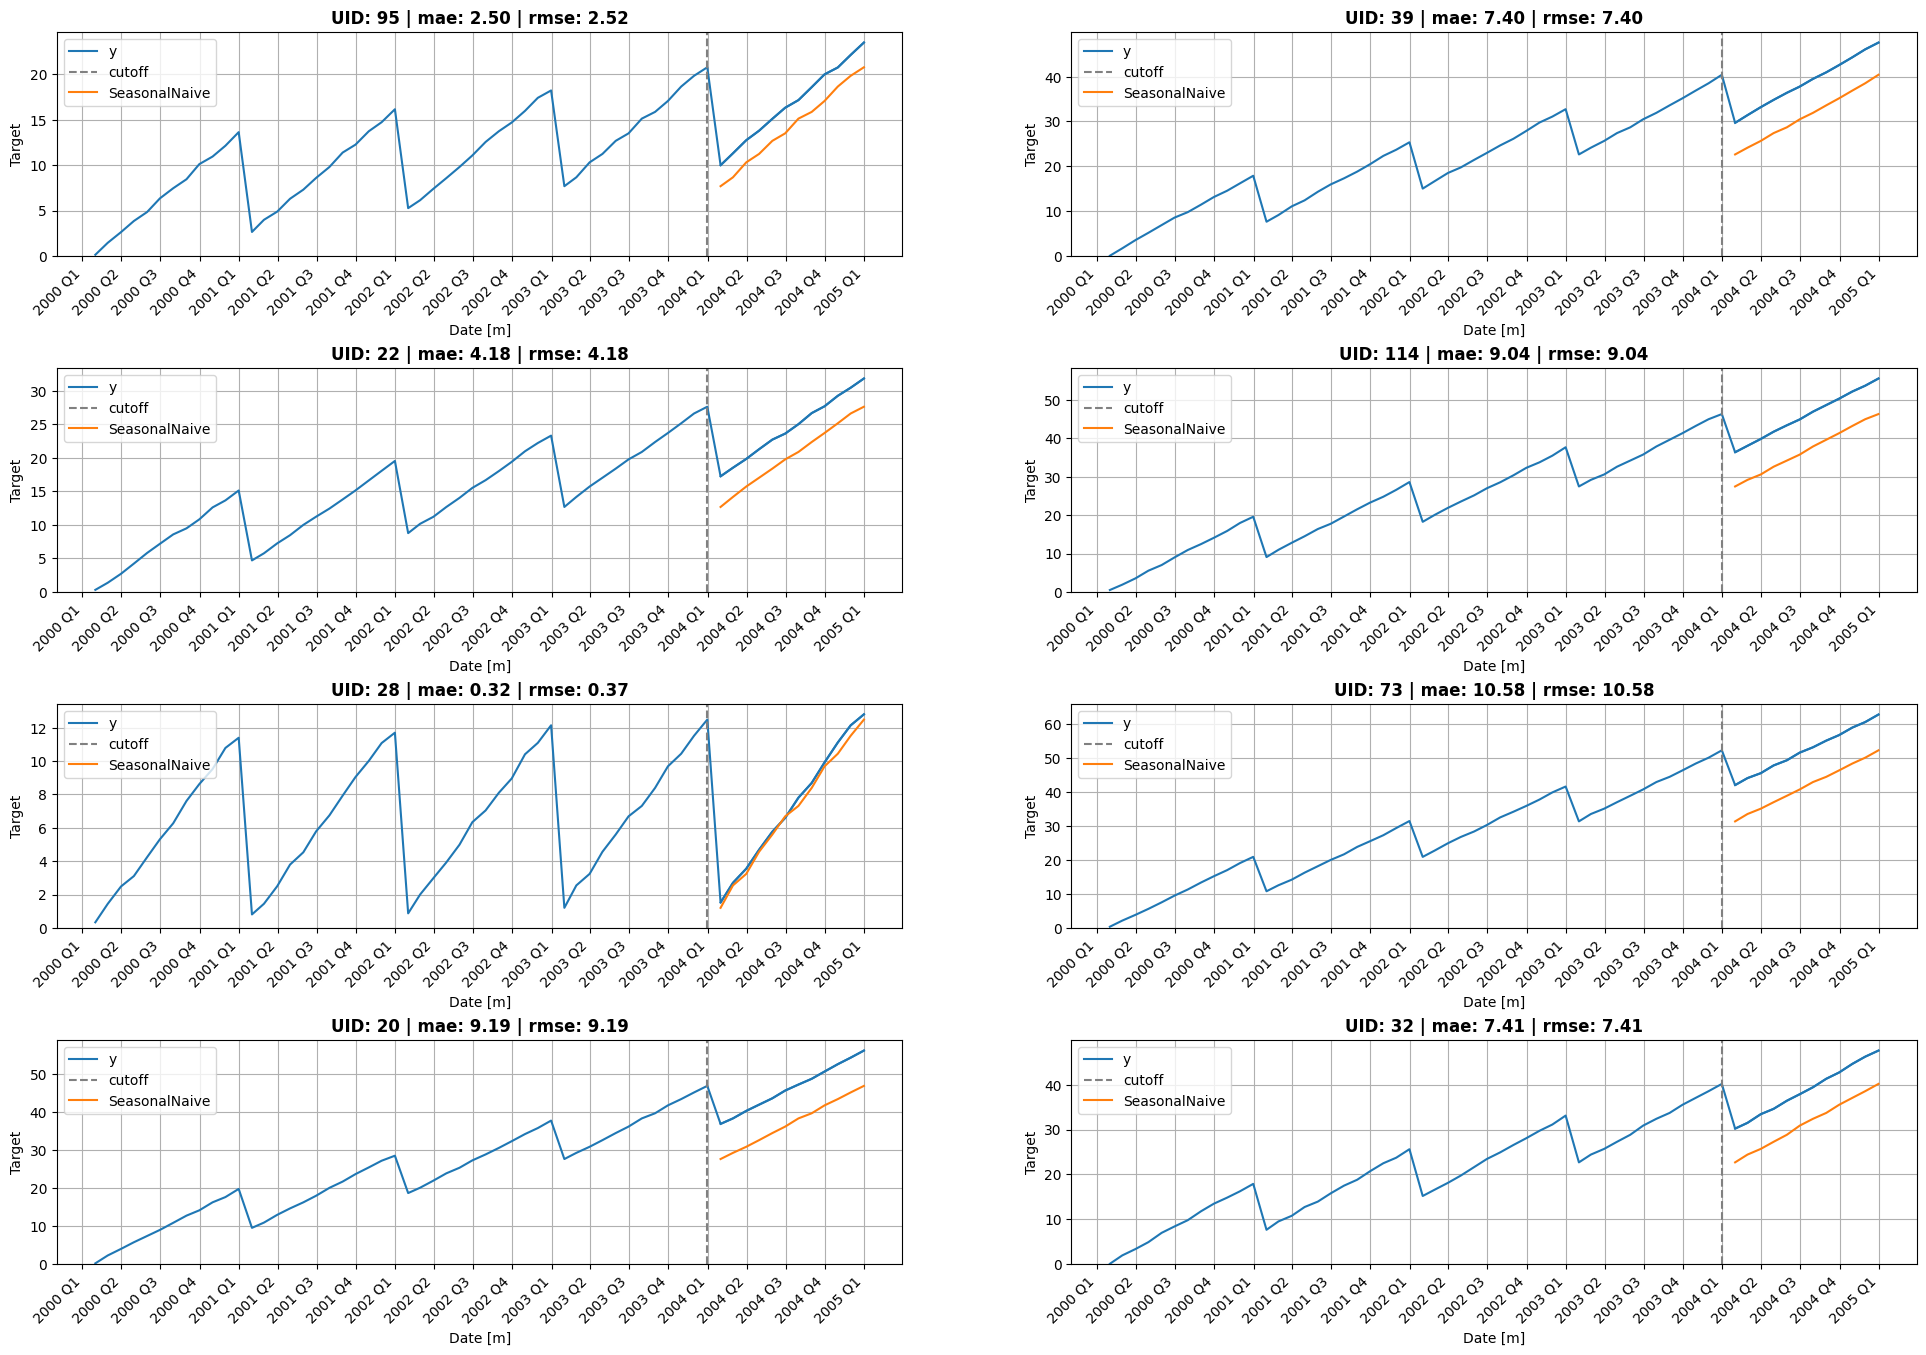

In [ ]:
plot_grid(Y_df, cv_df.query("cutoff == @cutoff"),
          df_eval.query("cutoff == @cutoff"),
          model='SeasonalNaive', descs=descs, date_fmt="quarter")

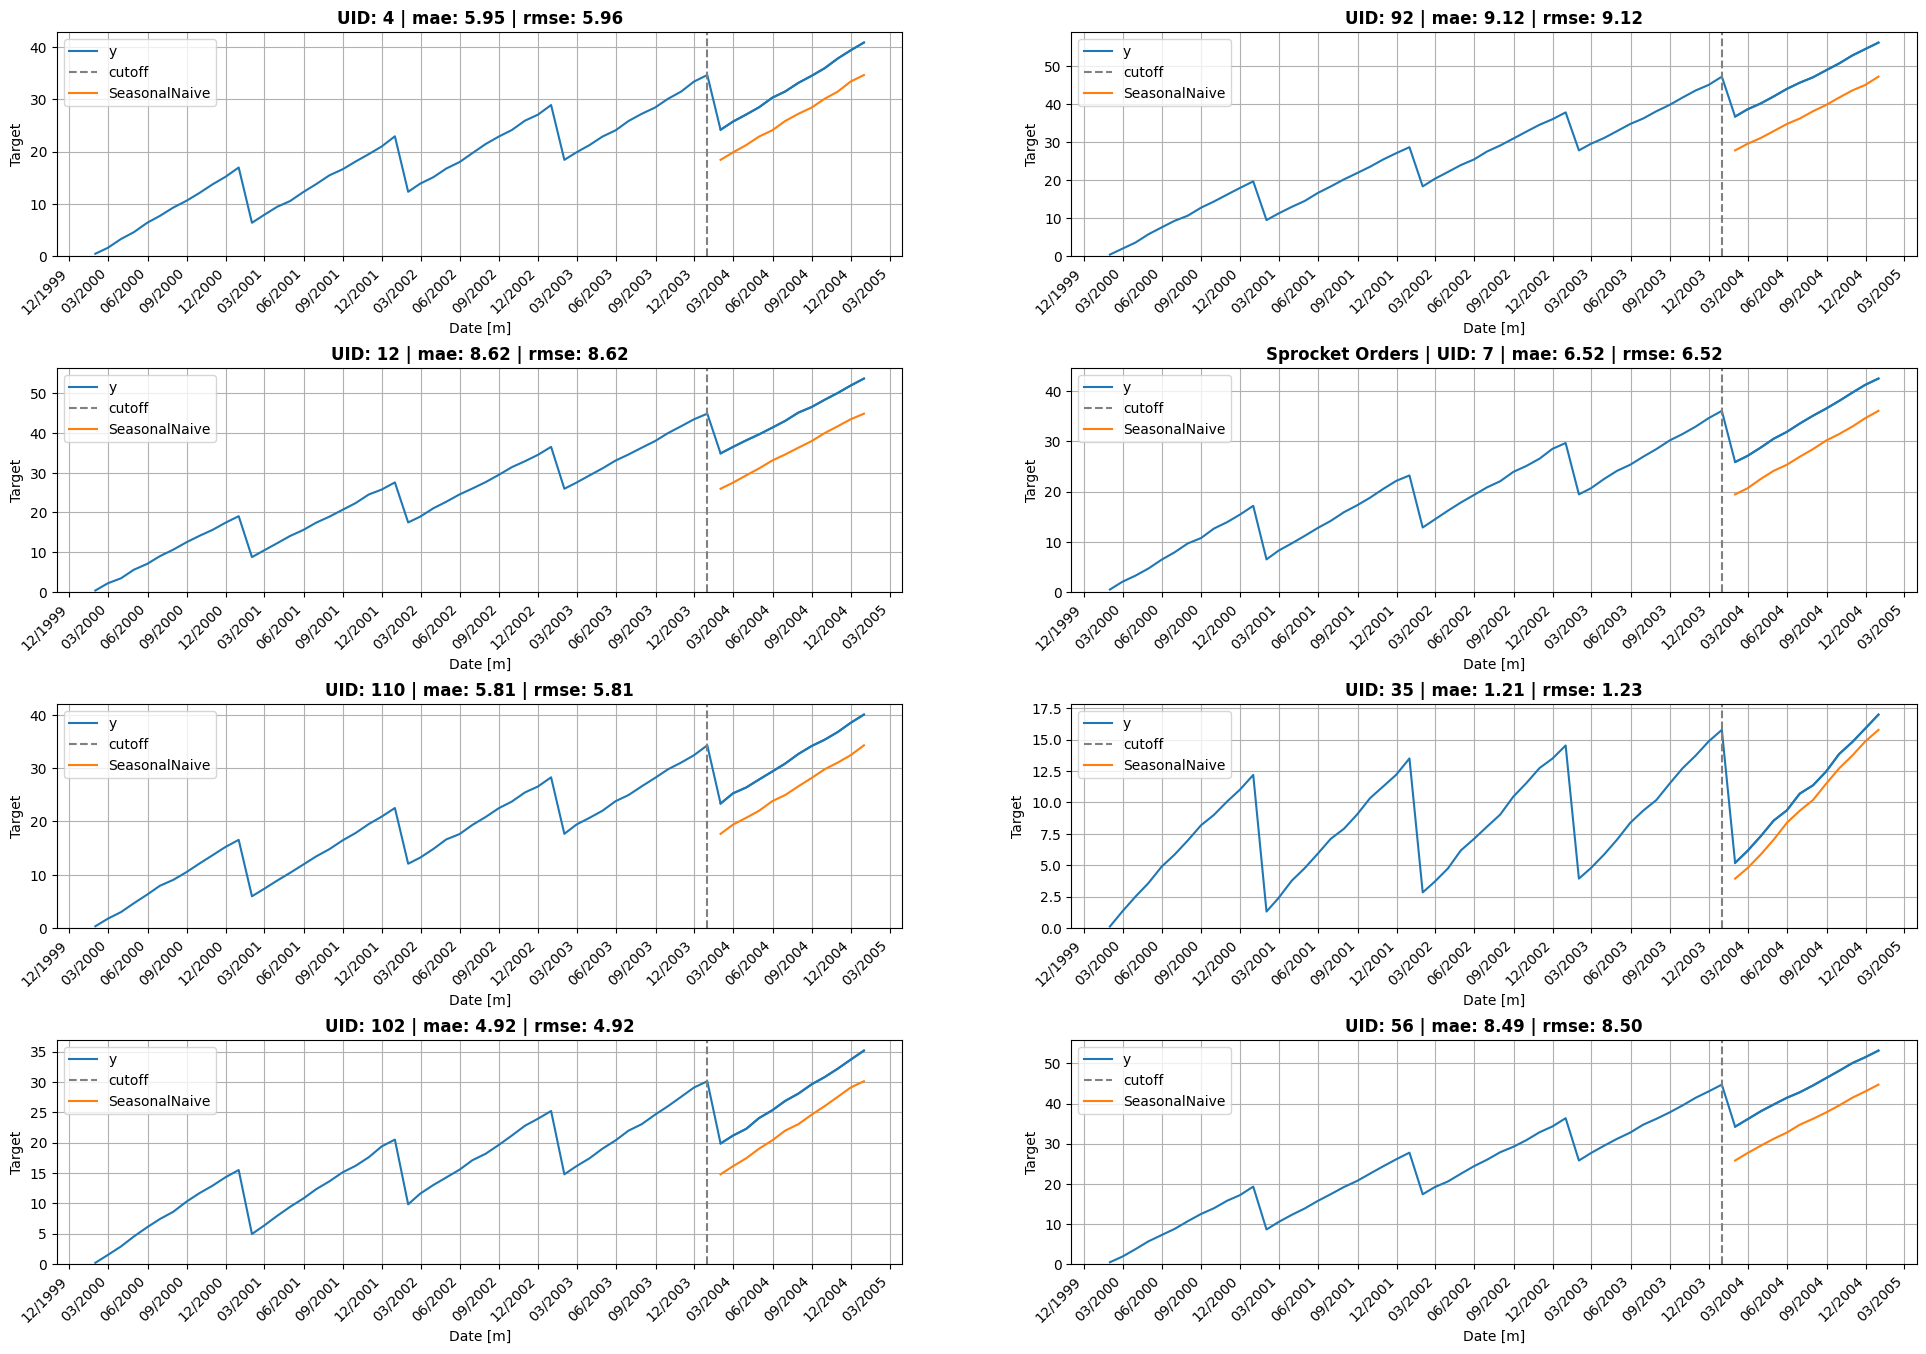

In [ ]:
plot_grid(Y_df, cv_df.query("cutoff == @cutoff"),
          df_eval.query("cutoff == @cutoff"),
          model='SeasonalNaive', descs=descs, date_fmt="month")

In [ ]:
def select_uids(df_eval, model, metric='mae', mode='random', k=8):
    "Select k unique_ids: 'random', 'top' (best), or 'flop' (worst) by metric"
    sub = df_eval.query("metric == @metric")
    if mode == 'random': return random.sample(list(sub['unique_id'].unique()), k=k)
    ascending = mode == 'top'
    return sub.nsmallest(k, model)['unique_id'].tolist() if ascending else sub.nlargest(k, model)['unique_id'].tolist()

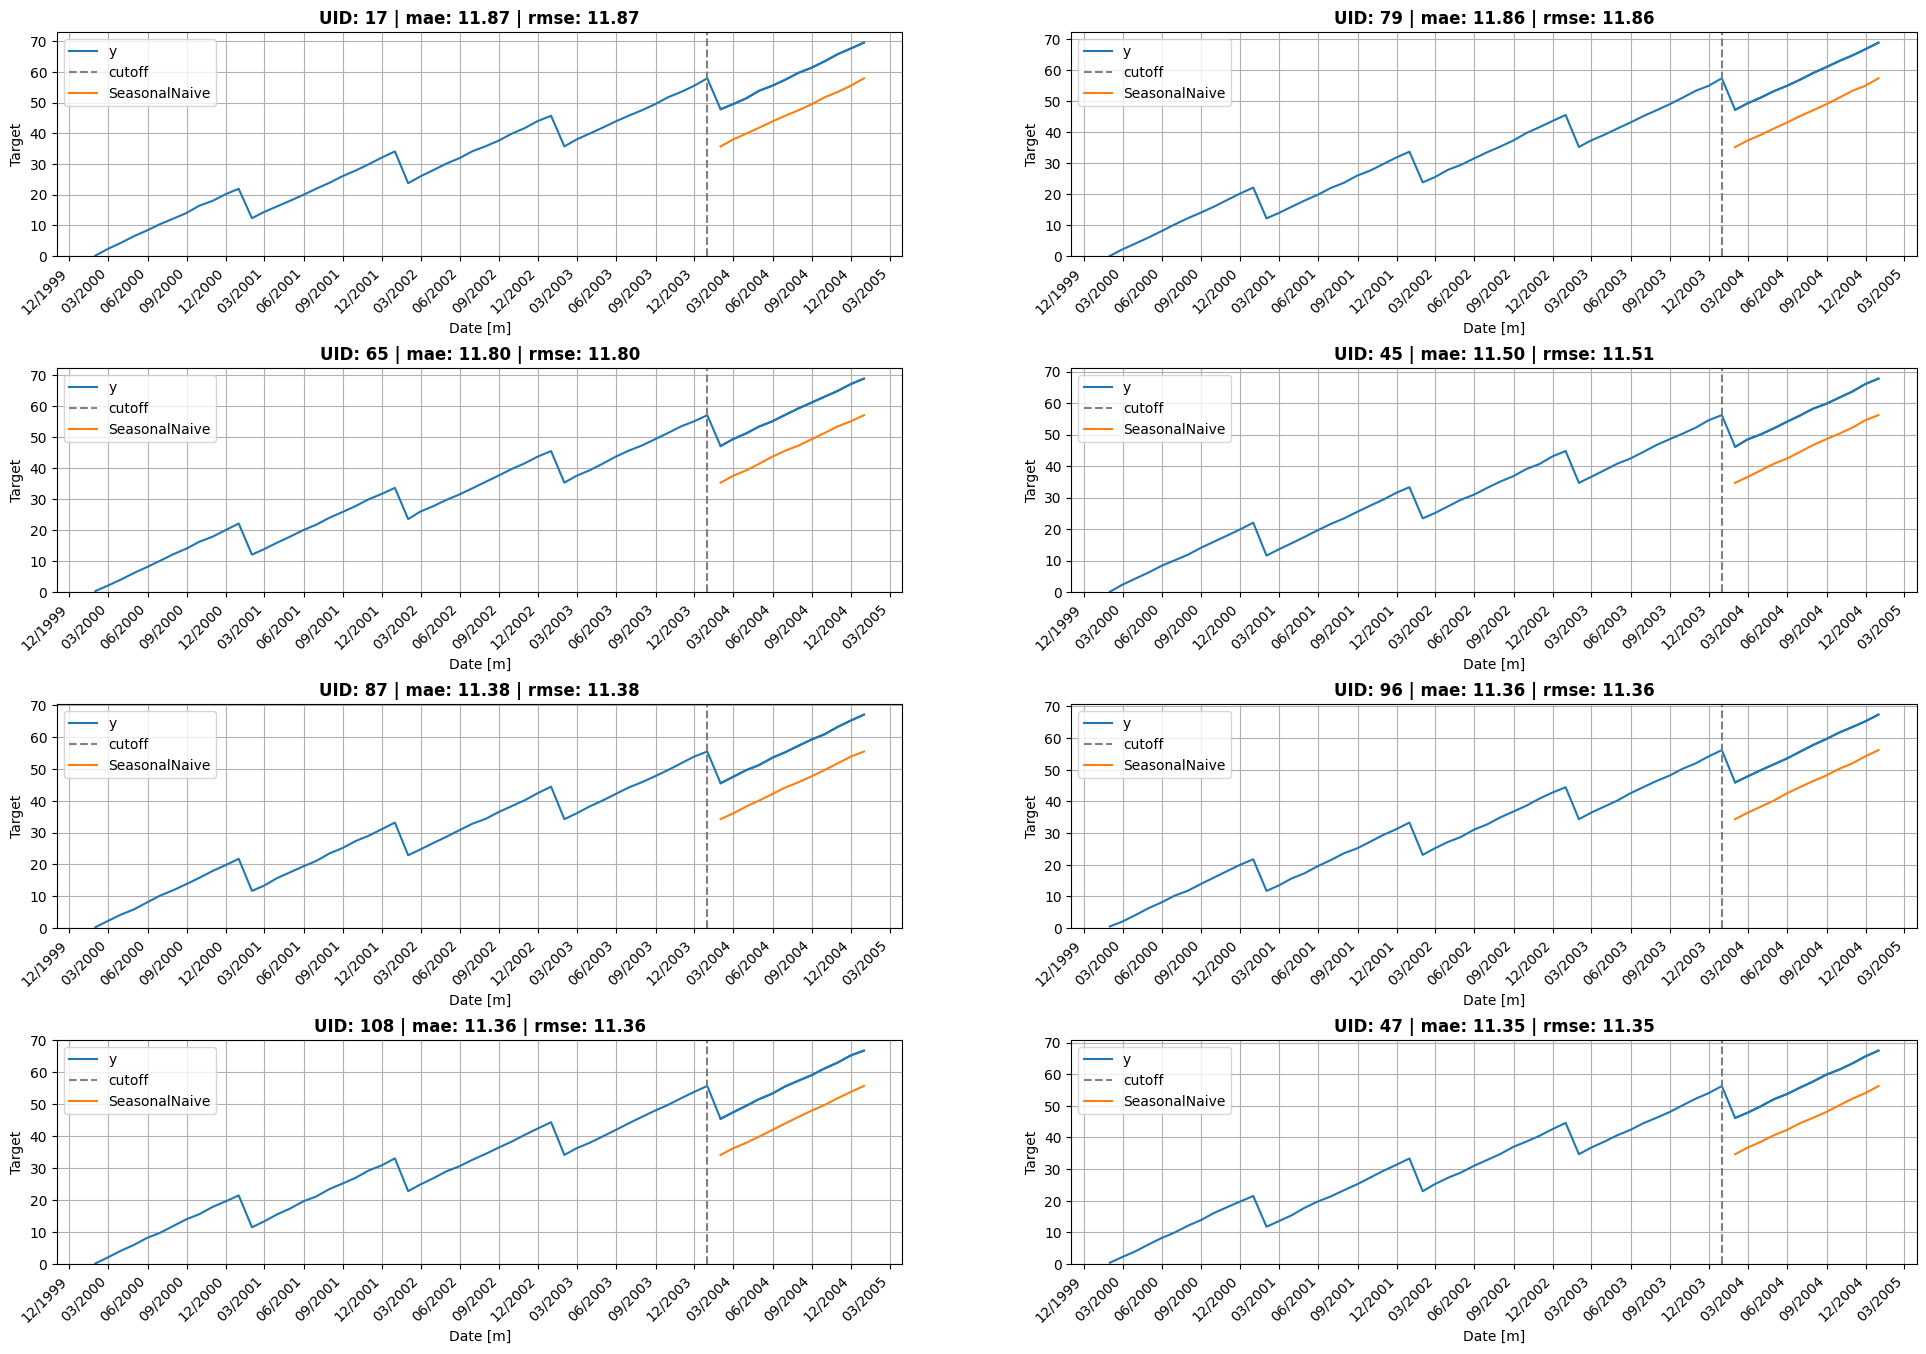

In [ ]:
uids = select_uids(df_eval.query("cutoff == @cutoff"), 'SeasonalNaive', metric='mae', mode='flop')
plot_grid(Y_df, cv_df.query("cutoff == @cutoff"),
          df_eval.query("cutoff == @cutoff"),
          model='SeasonalNaive', plot_random=False, ids=uids, date_fmt="month")

In [ ]:
def plot_grid_compact(df_train, df_test=None, df_eval=None, model=None, level=None, ids=None, descs=None, date_fmt=None, ncols=4, figw=28, rowh=3):
    if model is None and df_test is not None:
        models = [c for c in df_test.columns if c not in ('unique_id', 'ds', 'y', 'y_test', 'cutoff')]
        assert len(models) == 1, f"Multiple models found: {models}. Please specify `model`."
        model = models[0]
    if ids is None: ids = random.sample(list(df_train['unique_id'].unique()), k=min(16, len(df_train['unique_id'].unique())))
    nrows = -(-len(ids) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(figw, rowh * nrows), sharex='col', squeeze=False)
    handles, labels = [], []

    for i, uid in enumerate(ids):
        r, c = divmod(i, ncols)
        ax = axes[r][c]
        train_uid = df_train.query('unique_id == @uid')
        line, = ax.plot(train_uid['ds'], train_uid['y'], label='y')
        train_color = line.get_color()
        if df_test is not None:
            test_uid = df_test.query('unique_id == @uid')
            ax.axvline(x=test_uid['cutoff'].iloc[0], color='grey', linestyle='--', label='cutoff')
            for col in ['y', f'{model}', 'y_test']:
                if col not in test_uid: continue
                if col == 'y': ax.plot(test_uid['ds'], test_uid[col], color=train_color, label='_nolegend_')
                else: ax.plot(test_uid['ds'], test_uid[col], label=col)
            if level is not None:
                for l, alpha in zip(sorted(level), [0.5, .4, .35, .2]):
                    ax.fill_between(test_uid['ds'], test_uid[f'{model}-lo-{l}'], test_uid[f'{model}-hi-{l}'], alpha=alpha, color='orange', label=f'{model}_level_{l}')
        title = f'UID: {uid}'
        if descs is not None and uid in descs['unique_id'].values:
            title = f"{descs.query('unique_id == @uid')['desc'].values[0]} | {title}"
        if df_eval is not None and model is not None:
            eval_uid = df_eval.query('unique_id == @uid')
            if not eval_uid.empty and model in eval_uid.columns:
                metrics = ' | '.join(f'{r.metric}: {r[model]:.2f}' for _, r in eval_uid.iterrows())
                title += f' | {metrics}'
        ax.set_title(title, fontsize=9, fontweight='bold')
        ax.set_ylim(bottom=0)
        ax.grid(True, alpha=0.3)
        if i == 0: handles, labels = ax.get_legend_handles_labels()
        if date_fmt in ('month', 'monthly'):
            ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
        elif date_fmt == 'quarter':
            ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
            ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{mdates.num2date(x):%Y} Q{(mdates.num2date(x).month-1)//3+1}"))
        if date_fmt and r == nrows - 1: plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    for i in range(len(ids), nrows * ncols): axes[divmod(i, ncols)].set_visible(False)
    fig.legend(handles, labels, loc='upper center', ncol=len(labels), bbox_to_anchor=(0.5, 1.02), fontsize=10)
    fig.subplots_adjust(hspace=0.45)
    plt.show()

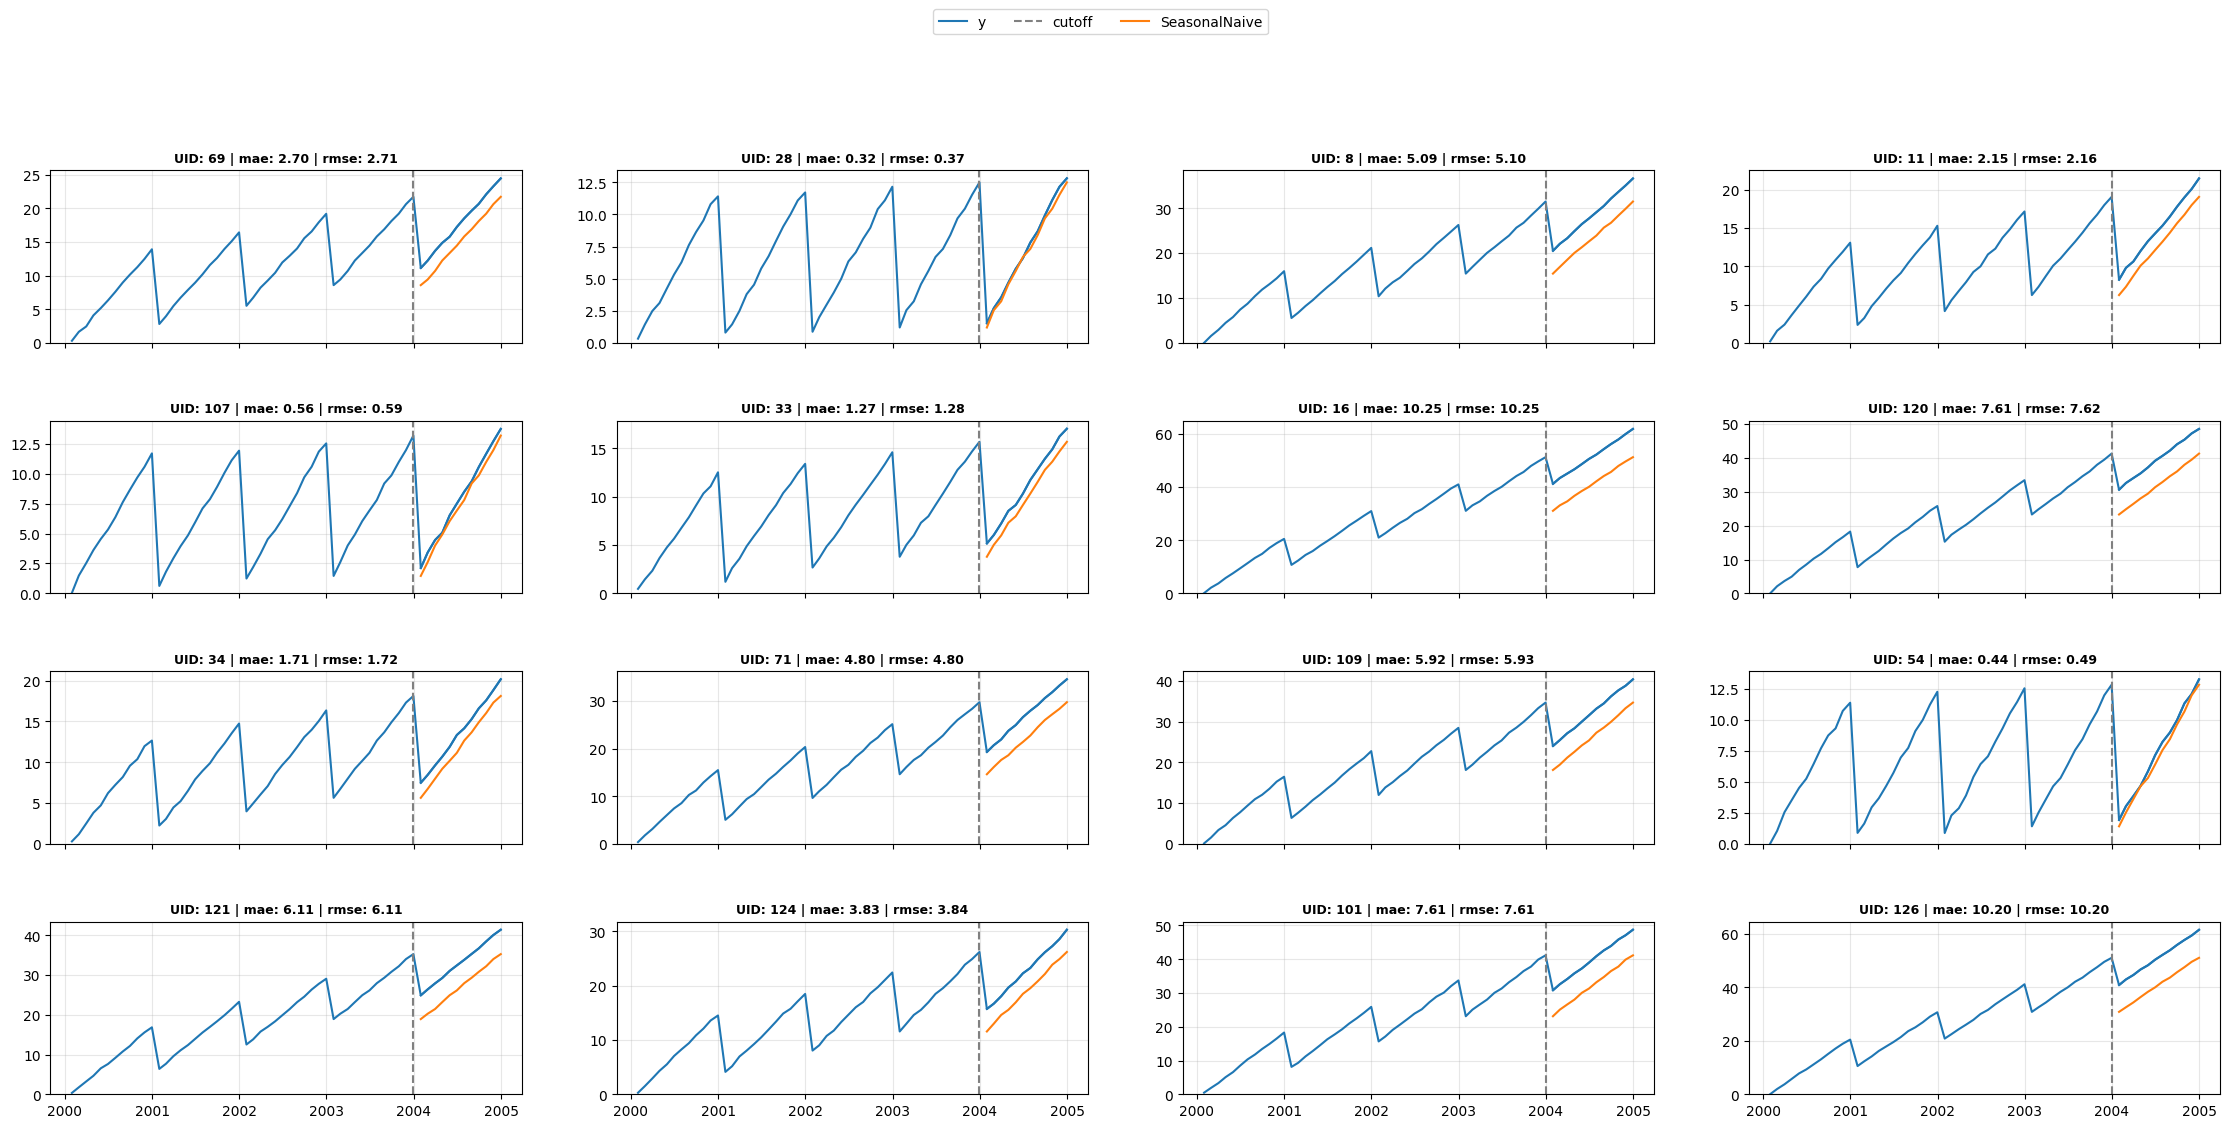

In [ ]:
plot_grid_compact(Y_df, cv_df.query("cutoff == @cutoff"), df_eval.query("cutoff == @cutoff"), model='SeasonalNaive', descs=descs)